In [1]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

In [2]:
def SPL(v, r=0):
    return 58 + 60*np.log10(8*v) - 20*np.log10(r)

In [ ]:
## Continuous Switching Control
# Constants
x0 = 0
xf = 100
N = 100  # Number of segments (stages)
sigma = 10 # Sensor's sharpness
sensor_pos = [25, 75]

# Parameters
v_modes = [1.0, 5.0, 10.0]
n_modes = [1.0, 25.0, 100.0]
# n_modes = [SPL(v_modes[0]), SPL(v_modes[1]), SPL(v_modes[2])]

opti = ca.Opti()
# Decision Variables
dt = opti.variable(N)      # How long to stay in each stage
# Binary matrix (N stages x 3 modes)
b = opti.variable(N, 3)    

total_risk = 0
current_x = x0
total_time = 0

for k in range(N):
    # Ensure only one mode is active per stage
    opti.subject_to(b[k,0] + b[k,1] + b[k,2] == 1)
    opti.subject_to(opti.bounded(0, b[k,:], 1)) # Binary approximation
    
    # Calculate Velocity and Noise for this stage
    v_k = b[k,0]*v_modes[0] + b[k,1]*v_modes[1] + b[k,2]*v_modes[2]
    n_k = b[k,0]*n_modes[0] + b[k,1]*n_modes[1] + b[k,2]*n_modes[2]
    
    # Dynamics
    dist_k = v_k * dt[k]
    
    # Risk at start and end of segment (Trapezoidal integration)
    segment_risk = 0
    for si in range(len(sensor_pos)):
        r_start = n_k * ca.exp(-ca.fabs(current_x - sensor_pos[si])/sigma)
        r_end = n_k * ca.exp(-ca.fabs((current_x + dist_k) - sensor_pos[si])/sigma)
        segment_risk += 0.5 * (r_start + r_end) * dt[k]
    
    total_risk += segment_risk
    total_time += dt[k]
    current_x += dist_k

# Constraints
opti.subject_to(current_x == xf) # Reach the goal
opti.subject_to(dt >= 0.1)        # Minimum time per segment

# Multi-objective: Minimize Time + Risk
objective_weight = [25, 1] # [Time Weight, Risk Weight]
binary_penalty = 10 * ca.sum2(ca.sum1(b * (1 - b)))
switch_penalty = 0
for k in range(N-1):
    # Penalize the squared difference between mode selection in consecutive stages
    # This 'smooths' the decision chain
    switch_penalty += ca.sumsqr(b[k+1, :] - b[k, :])
opti.minimize(objective_weight[0]*total_time + objective_weight[1]*total_risk + binary_penalty + 2.5*switch_penalty)

# Solve (Using IPOPT with relaxation or Bonmin for true integers)
opti.solver('ipopt')
sol = opti.solve()

# Interpret the "Decision Chain"
chosen_modes = np.argmax(sol.value(b), axis=1) + 1
final_time_hybrid = sol.value(total_time)
final_risk = sol.value(total_risk)
final_dts_hybrid = sol.value(dt)
print(f"--- Mission Results ---")
print(f"Total Time: {final_time_hybrid:.2f} seconds")
print(f"Total Risk: {final_risk:.4f} units")
# print(f"Durations per segment: {final_dts}")
# print(f"Optimal Mode Sequence: {chosen_modes}")

# Extract the actual positions at each switch
positions = []
curr_p = 0
for k in range(N):
    v_idx = chosen_modes[k] - 1
    dist = v_modes[v_idx] * final_dts_hybrid[k]
    curr_p += dist
    positions.append(curr_p)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      700
Number of nonzeros in inequality constraint Jacobian.:      400
Number of nonzeros in Lagrangian Hessian.............:    80200

Total number of variables............................:      400
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      101
Total number of inequality c

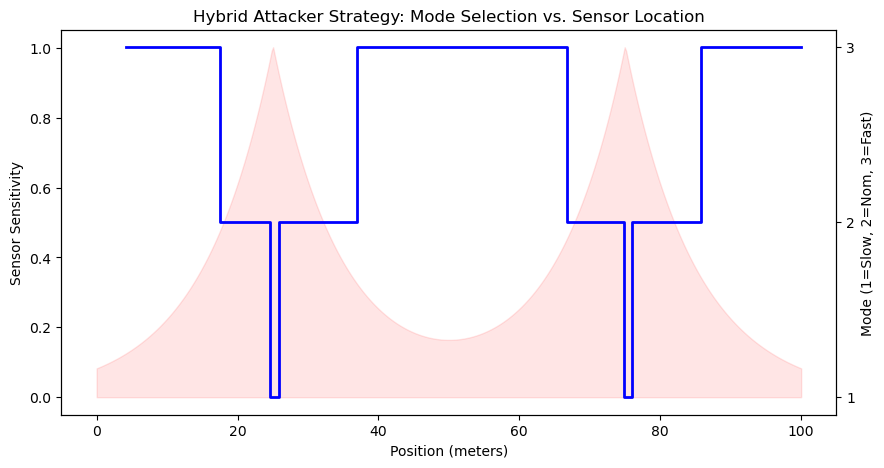

In [4]:
##########################
# --- Visulization ---
##########################
save_this = False

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot the Sensor Range for context (The 'Danger Zone')
x_range = np.linspace(0, 100, 500)
total_risk = np.linspace(0, 100, 500)*0
for si in range(len(sensor_pos)):
    risk_curve = np.exp(-np.abs(x_range - sensor_pos[si])/sigma)
    total_risk += risk_curve
ax1.fill_between(x_range, total_risk, color='red', alpha=0.1, label='Sensor Sensitivity')
ax1.set_ylabel('Sensor Sensitivity')
ax1.set_xlabel('Position (meters)')

# Plot the chosen modes
ax2 = ax1.twinx()
ax2.step(positions, chosen_modes, where='post', color='blue', linewidth=2, label='Selected Mode')
ax2.set_ylabel('Mode (1=Slow, 2=Nom, 3=Fast)')
ax2.set_yticks([1, 2, 3])

plt.title("Hybrid Attacker Strategy: Mode Selection vs. Sensor Location")
if save_this:
    fig.savefig('hybrid_test_double_sensor.png', dpi=300, bbox_inches='tight')

In [5]:
# 1. Fresh Instance
opti_c = ca.Opti()

# 2. Decision Variables (Specific to opti_c)
N = 100
v_c = opti_c.variable(N)    
dt_c = opti_c.variable(N)   

# 3. Parameters
w_time = objective_weight[0]
w_risk = objective_weight[1]

total_time_c = 0.0
total_risk_c = 0.0
current_x_c = 0.0

for k in range(N):
    dist_k = v_c[k] * dt_c[k]
    
    # SPL Calculation (Safe log to avoid NaN)
    spl_k = 58 + 60 * (ca.log(ca.fmax(1e-6, 8 * v_c[k])) / ca.log(10))
    
    # NORMALIZATION: Scale intensity so 120dB = 1.0 risk unit
    # This prevents the 10^12 explosion
    intensity_k = 10**((spl_k - 120) / 10) 
    
    segment_risk = 0.0
    for si in range(len(sensor_pos)):
        r_start = intensity_k * ca.exp(-ca.fabs(current_x_c - sensor_pos[si]) / sigma)
        r_end = intensity_k * ca.exp(-ca.fabs((current_x_c + dist_k) - sensor_pos[si]) / sigma)
        segment_risk += 0.5 * (r_start + r_end) * dt_c[k]
    
    total_risk_c += segment_risk
    total_time_c += dt_c[k]
    current_x_c += dist_k

# 4. Constraints
opti_c.subject_to(current_x_c == xf) 
opti_c.subject_to(opti_c.bounded(1, v_c, 10))
opti_c.subject_to(dt_c >= 0.01)

# 5. Initial Guesses (Crucial!)
opti_c.set_initial(v_c, 5)
opti_c.set_initial(dt_c, 1)

# 6. Solve
opti_c.minimize(w_time * total_time_c + w_risk * total_risk_c)
opti_c.solver('ipopt')
sol = opti_c.solve()

# Extract and Print
print(f"Total Time: {sol.value(total_time_c):.2f}s")
print(f"Total Risk: {sol.value(total_risk_c):.4f}")

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      200
Number of nonzeros in inequality constraint Jacobian.:      200
Number of nonzeros in Lagrangian Hessian.............:    20100

Total number of variables............................:      200
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:      200
        inequality constraints with only lower bounds:      100
   inequality constraints with lower and upper bounds:      100
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.3168158e+04 4.00e+02 4.98e+01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [7]:
print('From Continuous:')
print(f"Total Time: {sol.value(total_time_c):.2f}s")
print(f"Total Risk: {sol.value(total_risk_c):.4f}")

print('\n')
print('From Hybrid System')
print(f"Total Time: {final_time_hybrid:.2f} seconds")
print(f"Total Risk: {final_risk:.4f} units")

From Continuous:
Total Time: 40.24s
Total Risk: 199.8108


From Hybrid System
Total Time: 14.73 seconds
Total Risk: 263.1543 units
